In [29]:
# pip install vireoSNP

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import vireoSNP

In [2]:
cwd = os.getcwd()

In [5]:
def match_sample_id():
    
    # match bulk to dissociated bulk
    res = vireoSNP.vcf.match_VCF_samples(
        cwd + "/../data/bcftools/bcftools_filter_DP900_all_samples.vcf", 
        cwd + "/../data/bcftools/bcftools_filter_DP900_all_samples.vcf", 
        GT_tag1='PL', 
        GT_tag2='PL',
    )
    
    df = pd.DataFrame(
        {
            "diss bulk sample id": res["matched_donors2"],
            "bulk sample id": res["matched_donors1"],
        }
    )
    # Clean up "sample id" columns
    df = df.replace({r"\d{6}/": ""}, regex=True)
        
    return res, df

In [6]:
res, df = match_sample_id()

Shape for Geno Prob in VCF1: (260772, 66, 3)
Shape for Geno Prob in VCF2: (260772, 66, 3)
n_variants in VCF1, VCF2 and matched: 260772, 260772, 260772
aligned donors:
['230509/2018' '230509/2023' '230509/2094' '230509/2126' '230509/2129'
 '230509/2186' '230509/2202' '230509/2209' '230509/2240' '230509/2309'
 '230509/2313' '230509/2401' '230509/2407' '230509/2444' '230509/2483'
 '230509/2526' '230626/2216' '230626/2221' '230626/2230' '230626/2238'
 '230626/2246' '230626/2249' '230626/2268' '230626/2278' '230626/2296'
 '230626/2364' '230626/2408' '230626/2416' '230626/2423' '230626/2430'
 '230626/2455' '230626/2460' '230626/2466' '230626/2477' '230626/2514'
 '230414/2018' '230414/2126' '230414/2202' '230414/2221' '230414/2240'
 '230414/2278' '230414/2364' '230414/2407' '230414/2416' '230414/2477'
 '230414/2023' '230414/2129' '230414/2209' '230414/2238' '230414/2249'
 '230414/2313' '230414/2401' '230414/2408' '230414/2460' '230414/2483'
 '230414/2526' '230418/2094' '230418/2186' '230418/2

In [25]:
pair_df = df.copy()
df = pd.DataFrame(
    res["matched_GPb_diff"],
    columns=res["matched_donors2"],
    index=res["matched_donors1"],
)

In [8]:
df.columns = df.columns.str.replace(r"\d{6}/", "", regex=True)

In [9]:
df.index = df.index.str.replace(r"\d{6}/", "", regex=True)

In [26]:
df

,230509/2018,230509/2023,230509/2094,230509/2126,230509/2129,230509/2186,230509/2202,230509/2209,230509/2240,230509/2309,...,230418/2094,230418/2186,230418/2216,230418/2230,230418/2246,230418/2309,230418/2423,230418/2455,230418/2466,230418/2514
230509/2018,0.000000,0.188029,0.185827,0.185460,0.212138,0.193924,0.189188,0.198073,0.189874,0.202209,...,0.294989,0.296874,0.302659,0.327176,0.312930,0.310145,0.307460,0.307496,0.314617,0.322458
230509/2023,0.188029,0.000000,0.187775,0.191540,0.212805,0.195206,0.190763,0.200105,0.190842,0.203475,...,0.295021,0.296400,0.303033,0.325607,0.311888,0.307363,0.309290,0.306828,0.312284,0.321416
230509/2094,0.185827,0.187775,0.000000,0.190716,0.210787,0.192581,0.186217,0.199673,0.190199,0.202460,...,0.198989,0.295270,0.304011,0.327445,0.312190,0.310275,0.310198,0.306090,0.313729,0.319493
230509/2126,0.185460,0.191540,0.190716,0.000000,0.212008,0.191650,0.190986,0.198631,0.189767,0.200612,...,0.294409,0.292066,0.300012,0.324908,0.308671,0.310786,0.307012,0.306156,0.312706,0.318793
230509/2129,0.212138,0.212805,0.210787,0.212008,0.000000,0.213447,0.214466,0.219161,0.211622,0.213927,...,0.296235,0.296511,0.302164,0.316596,0.306729,0.308000,0.306971,0.298129,0.308382,0.313881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230418/2309,0.310145,0.307363,0.310275,0.310786,0.308000,0.311928,0.309423,0.306606,0.309611,0.302979,...,0.175399,0.182007,0.175144,0.171905,0.172955,0.000000,0.164127,0.178826,0.173212,0.195814
230418/2423,0.307460,0.309290,0.310198,0.307012,0.306971,0.307016,0.309867,0.303424,0.308146,0.293833,...,0.177292,0.173839,0.168833,0.159865,0.170121,0.164127,0.000000,0.169557,0.176745,0.194080
230418/2455,0.307496,0.306828,0.306090,0.306156,0.298129,0.302605,0.306297,0.309924,0.307269,0.293482,...,0.172364,0.171910,0.176029,0.174070,0.167829,0.178826,0.169557,0.000000,0.174231,0.187236
230418/2466,0.314617,0.312284,0.313729,0.312706,0.308382,0.310982,0.313358,0.321543,0.315098,0.304673,...,0.175498,0.177269,0.185282,0.171810,0.158474,0.173212,0.176745,0.174231,0.000000,0.196994


In [ ]:
# df.to_csv(cwd + "/../data/bcftools/heatmap_raw_bulk_v_diss_bulk_filter4.csv", index=True)

In [ ]:
# pair_df = pd.DataFrame(
#     {
#         "bulk sample id": res["matched_donors1"],
#         "diss bulk sample id": res["matched_donors2"],
#     }
# )

In [11]:
pair_df.sort_values(by="bulk sample id")

,diss bulk sample id,bulk sample id
0,2018,2018
35,2018,2018
1,2023,2023
45,2023,2023
56,2094,2094
...,...,...
14,2483,2483
34,2514,2514
65,2514,2514
15,2526,2526


In [150]:
extra_df = pd.read_csv(cwd + "/../data/bcftools/heatmap_raw_bulk_v_diss_bulk_filter4.csv", index_col=0)

In [151]:
extra_df = extra_df.loc[[2018, 2023, 2094, 2126, 2129]]

In [152]:
extra_df

,2018,2023,2094,2126,2129,2186,2202,2216,2246,2313,...,2278,2401,2416,2309,2423,2460,2466,2477,2483,2514
2018,0.023158,0.178846,0.175142,0.170035,0.178226,0.176731,0.172711,0.187050,0.179779,0.205365,...,0.187459,0.173651,0.220273,0.190621,0.185358,0.175236,0.178240,0.173811,0.180425,0.227560
2023,0.178282,0.029563,0.176936,0.177699,0.177327,0.177078,0.172251,0.186851,0.182401,0.206980,...,0.186857,0.171296,0.223198,0.190457,0.188496,0.179045,0.180150,0.172407,0.179863,0.226020
2094,0.176265,0.177039,0.022737,0.177075,0.175566,0.177312,0.169135,0.190543,0.182254,0.205824,...,0.191604,0.173255,0.223159,0.193734,0.193473,0.177847,0.180796,0.174573,0.184169,0.225088
2126,0.170341,0.177425,0.176833,0.024424,0.176662,0.170672,0.170815,0.186026,0.174747,0.203547,...,0.186925,0.172331,0.217159,0.192688,0.185961,0.178583,0.177824,0.172937,0.178388,0.224370
2129,0.187239,0.187064,0.186357,0.185596,0.049986,0.187040,0.188063,0.198661,0.188574,0.205367,...,0.195992,0.183438,0.228444,0.197293,0.199323,0.191755,0.190385,0.186592,0.191107,0.221346


In [153]:
df = pd.concat([df, extra_df])

In [154]:
df.shape

(36, 31)

In [27]:
sample_order_df = pd.DataFrame(
    {"samples": sorted(set(df.columns) | set(df.index))}
)
sample_order_df["sample_id"] = sample_order_df["samples"].str[-4:]
sample_order_df["date"] = sample_order_df["samples"].str[:4]
sample_order_df.loc[sample_order_df["date"]=="2304", "sample_type"] = "diss_bulk"
sample_order_df.loc[sample_order_df["date"]!="2304", "sample_type"] = "bulk"
sample_order_df = sample_order_df.sort_values(by=["sample_type", "sample_id"])

sample_order_df

sample_order_lst = list(sample_order_df["samples"])

sorted_df = df[sample_order_lst]
sorted_df = sorted_df.loc[sample_order_lst]


In [ ]:
# df.index = df.index.astype(str)

# sorted_df = df[sorted(df.columns)]
# sorted_df = sorted_df.loc[sorted(sorted_df.index)]

In [21]:
set(sorted_df.columns) - set(sorted_df.index)

set()

In [22]:
set(sorted_df.index) - set(sorted_df.columns)

set()

In [23]:
sorted_df.shape

(66, 66)

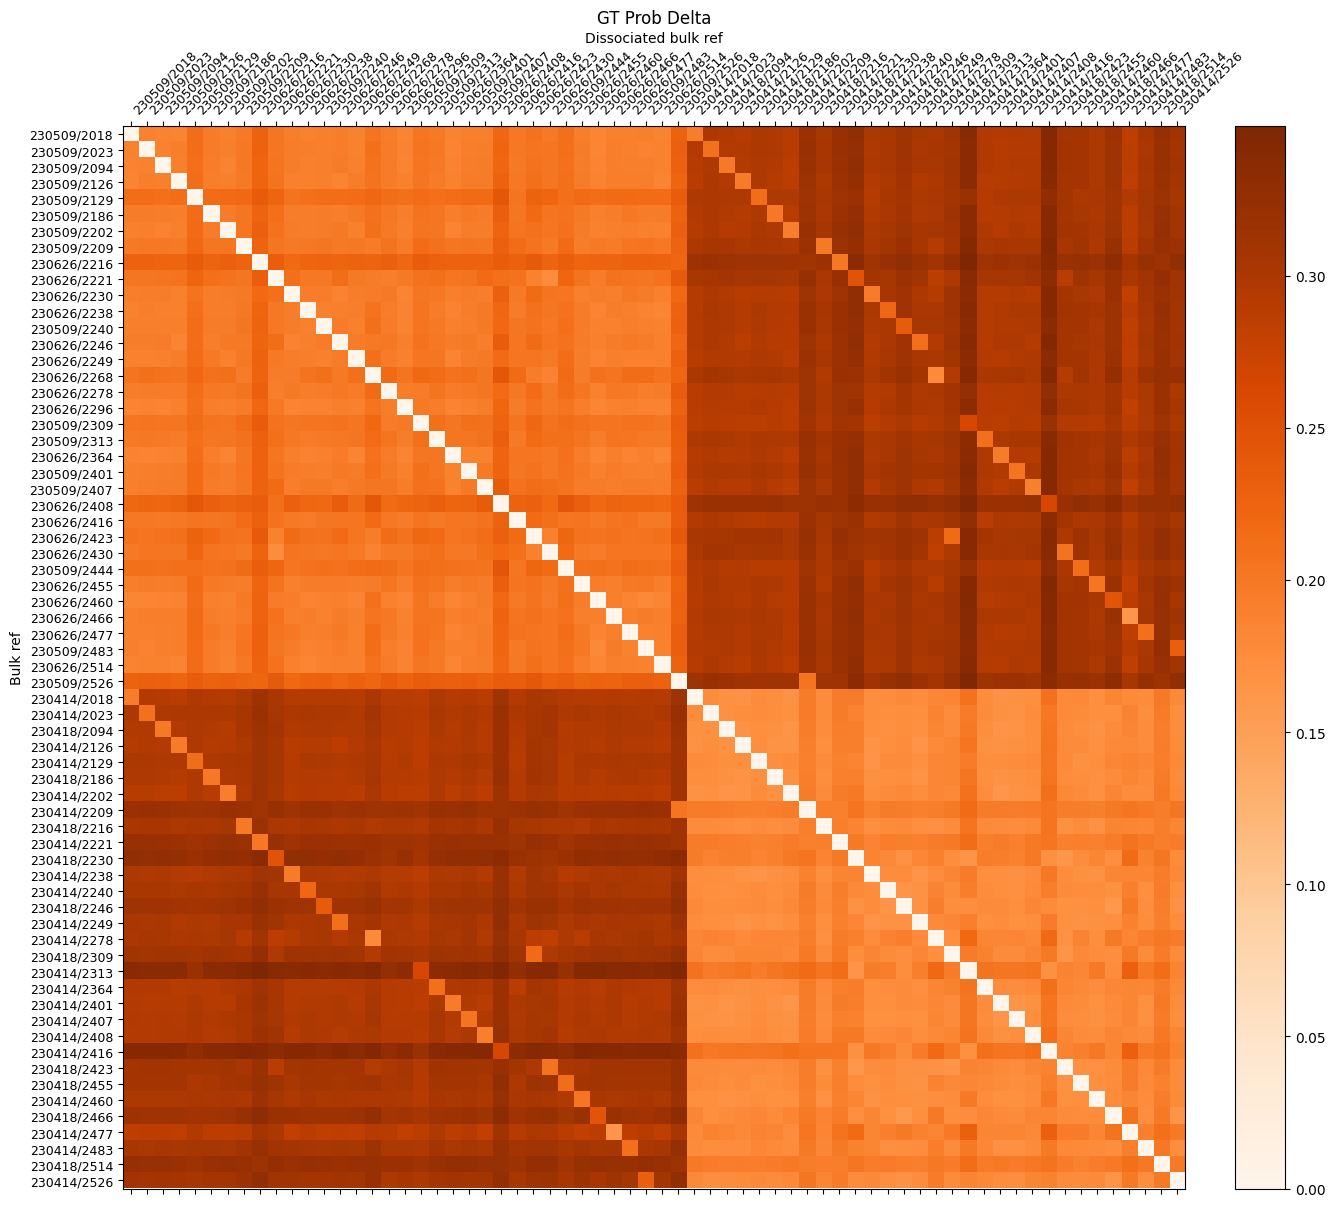

In [32]:
fig, ax = plt.subplots(figsize=(15, 15))
heatmap = ax.matshow(sorted_df, cmap="Oranges")

# Pool lines
# plt.axhline(y=3.5, color='black', linestyle='--')
# plt.axhline(y=6.5, color='black', linestyle='--')
# plt.axhline(y=10.5, color='black', linestyle='--')
# plt.axhline(y=13.5, color='black', linestyle='--')
# plt.axhline(y=16.5, color='black', linestyle='--')
# plt.axhline(y=20.5, color='black', linestyle='--')
# plt.axhline(y=23.5, color='black', linestyle='--')
# plt.axhline(y=27.5, color='black', linestyle='--')
# plt.axhline(y=30.5, color='black', linestyle='--')

# # Numbers in grid
# for (i, j), z in np.ndenumerate(sorted_df):
#     ax.text(j, i, "{:.2f}".format(z), ha="center", va="center", fontdict={"fontsize": 6})

ax.set_xticks(np.arange(len(df.columns)))
ax.set_yticks(np.arange(len(df)))
ax.set_xticklabels(sorted_df.columns, rotation=45, ha="left", fontdict={"fontsize": 9})
ax.set_yticklabels(sorted_df.index, fontdict={"fontsize": 9})
ax.xaxis.set_label_position("top")
ax.set_xlabel("Dissociated bulk ref")
ax.set_ylabel("Bulk ref")
ax.set_title("GT Prob Delta")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size=0.5, pad=0.5)
cbar = fig.colorbar(heatmap, cax=cax)

plt.show()

In [33]:
filename = f"../figures/diss_vs_bulk_ref/GT_delta_filter_dp900_w2507_all_samples"
fig.savefig(filename + ".pdf", bbox_inches="tight")
fig.savefig(filename + ".png", bbox_inches="tight")

# Comparing filtering vs no filtering

In [76]:
pair_no_filter = pd.read_csv(cwd + "/../data/sample_pairing_no-filter.csv")
pair_filter1 = pd.read_csv(cwd + "/../data/sample_pairing_filter1.csv")
pair_filter2 = pd.read_csv(cwd + "/../data/sample_pairing_filter2.csv")
pair_filter3 = pd.read_csv(cwd + "/../data/sample_pairing_filter3.csv")

In [153]:
df = pd.merge(pair_no_filter, pair_filter1, on="bulk sample id", suffixes=[" no", " 1"], how="outer")
df = pd.merge(df, pair_filter2, on="bulk sample id", how="outer")
df = pd.merge(df, pair_filter3, on="bulk sample id", suffixes=[" 2", " 3"], how="outer")

In [154]:
df = df.sort_values(by="bulk sample id").reset_index(drop=True)

In [155]:
df["bulk sample id"] = df["bulk sample id"].astype("str")
df["diss bulk sample id no"] = df["diss bulk sample id no"].astype("Int64").astype("str")
df["diss bulk sample id 1"] = df["diss bulk sample id 1"].astype("Int64").astype("str")
df["diss bulk sample id 2"] = df["diss bulk sample id 2"].astype("Int64").astype("str")
df["diss bulk sample id 3"] = df["diss bulk sample id 3"].astype("Int64").astype("str")

In [157]:
cmap=plt.colormaps["gist_rainbow"]

In [160]:
# Get all sample ids, sort, and remove the nan at the end
sample_ids = sorted(set(df["bulk sample id"]) | set(df["diss bulk sample id 1"]) | set(df["diss bulk sample id 2"]) | set(df["diss bulk sample id 3"]) | set(df["diss bulk sample id no"]))[:-1]

In [163]:
color_dict = {
    sample_ids[i]: i for i in range(len(sample_ids))
}

shadow_df = df.copy()
shadow_df.replace(color_dict, inplace=True)

/var/folders/yj/bt5772fx4p1cg9s9jbwzf0r00000gp/T/ipykernel_41197/2684966974.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shadow_df.replace(color_dict, inplace=True)


In [174]:
shadow_df.replace("<NA>", np.nan, inplace=True)

/var/folders/yj/bt5772fx4p1cg9s9jbwzf0r00000gp/T/ipykernel_41197/936780263.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shadow_df.replace("<NA>", np.nan, inplace=True)


In [179]:
shadow_df = shadow_df.astype(float)

In [199]:
reverse_dict = {v: k for k, v in color_dict.items()}

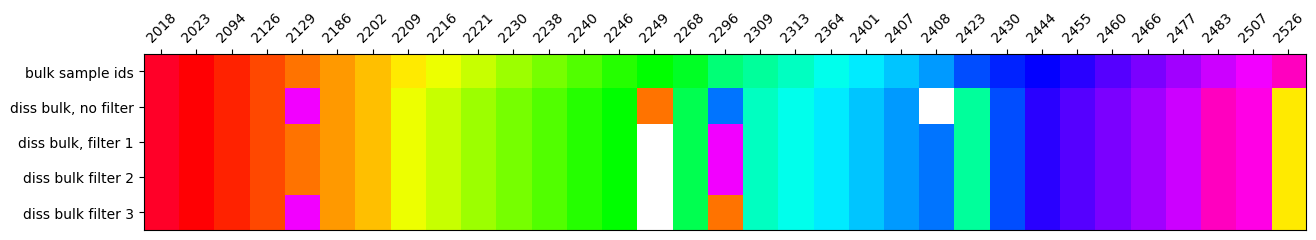

In [207]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))

cmap=plt.colormaps["gist_rainbow"]

plt.imshow(shadow_df.T, cmap="gist_rainbow")
ax.set_xticks(range(len(shadow_df)))
ax.set_xticklabels(
    labels=shadow_df["bulk sample id"].astype(int).replace(reverse_dict),
    rotation=45,
    )
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
ax.set_yticks(range(5))
ax.set_yticklabels(["bulk sample ids", "diss bulk, no filter", "diss bulk, filter 1", "diss bulk filter 2", "diss bulk filter 3"])

plt.show()

In [208]:
filename = f"../figures/diss_vs_bulk_ref/label_matching_heatmap"
fig.savefig(filename + ".pdf", bbox_inches="tight")
fig.savefig(filename + ".png", bbox_inches="tight")